# Case study

In [1]:
import traceback
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import netCDF4 as nc
import numpy as np
import xarray as xr
import cmocean
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

In [3]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      psd_var: str = 'psd',
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments[psd_var].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    psd_stack  = np.stack(rows_psd, axis=0)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
        ),
        coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
            lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
            lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

import cartopy.feature as cfeature
import matplotlib.ticker as mticker

def plot_box(var: np.array, lon: np.array, lat: np.array,
             box_deg: float = None,
             projection: ccrs = ccrs.Robinson(), cmap: str = "viridis",
             figsize: tuple = (14, 7), fig = None, ax = None,
             title: str = "Number of observations per box", label: str = "Number of observations",
             norm: norm = None, vmin: float = None, vmax: float = None
            ):
    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    # Infer box size from the spacing of box centers if not given
    if box_deg is None:
        lat_diffs = np.diff(np.unique(np.round(lat, 6)))
        lon_diffs = np.diff(np.unique(np.round(lon, 6)))
        box_deg = np.min(np.concatenate([lat_diffs, lon_diffs]))

    # Reconstruct the regular grid of box centers
    lat_centers = np.arange(lat.min(), lat.max() + box_deg, box_deg)
    lon_centers = np.arange(lon.min(), lon.max() + box_deg, box_deg)

    lat_idx = np.round((lat - lat_centers[0]) / box_deg).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / box_deg).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = var

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - box_deg / 2, [lat_centers[-1] + box_deg / 2]])
    lon_edges = np.concatenate([lon_centers - box_deg / 2, [lon_centers[-1] + box_deg / 2]])
    if ax==None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    if norm is not None:
        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), norm=norm)
    else:
        if vmin is None:
            vmin, vmax = np.nanmin(var), np.nanmax(var)

        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label(label)
    ax.set_title(title)

    return fig, ax
    

In [33]:
DATA_DIR          = '/Volumes/PortableSSD/diags_2024/'
SEGMENT_LENGTH_KM = 500.0
EXPERT_FILE       = f'swot_segments2D_{int(SEGMENT_LENGTH_KM)}km_demean.nc'
#UNSMOOTHED_FILE   = f'swot_unsmoothed_aliased_{int(SEGMENT_LENGTH_KM)}km.nc'

#---------- Box parameters ------------------------
BOX_DEG = 2.0
MIN_SAMPLING_FRACTION = 0.15

#---------- Regional parameters ------------------------
LON_MIN, LON_MAX = -75, -30
LAT_MIN, LAT_MAX = 20, 50

In [34]:
ds_segments_ex = xr.open_dataset(DATA_DIR+EXPERT_FILE)
ds_boxes       = build_box_dataset(ds_segments_ex, box_deg=BOX_DEG, min_sampling_fraction=MIN_SAMPLING_FRACTION)

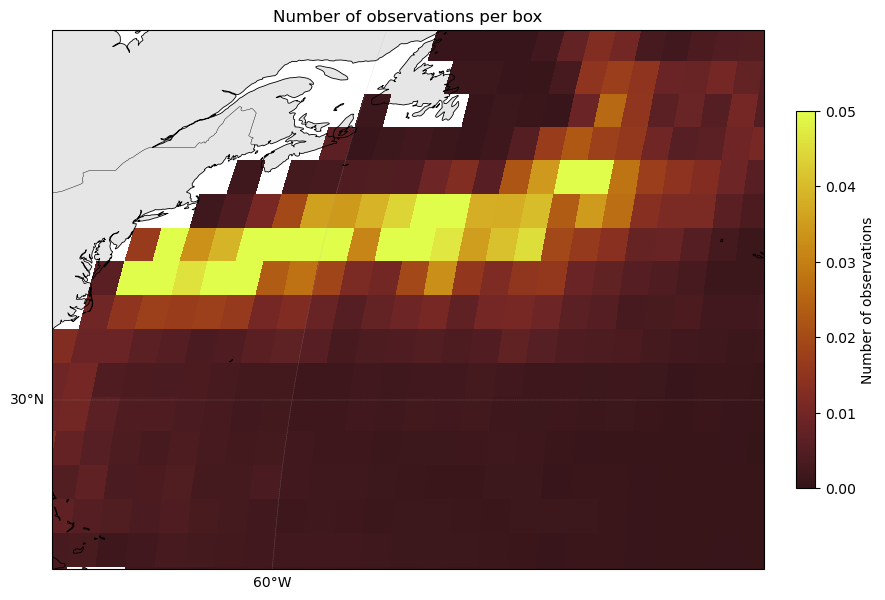

In [35]:
fig,ax = plot_box(ds_boxes.mean_psd.integrate('wavenumber'),
                  ds_boxes.lon_mean, ds_boxes.lat_mean,
                 cmap=cmocean.cm.solar, vmax=5e-2,vmin=0)
ax.set_extent([LON_MIN,LON_MAX,LAT_MIN,LAT_MAX])

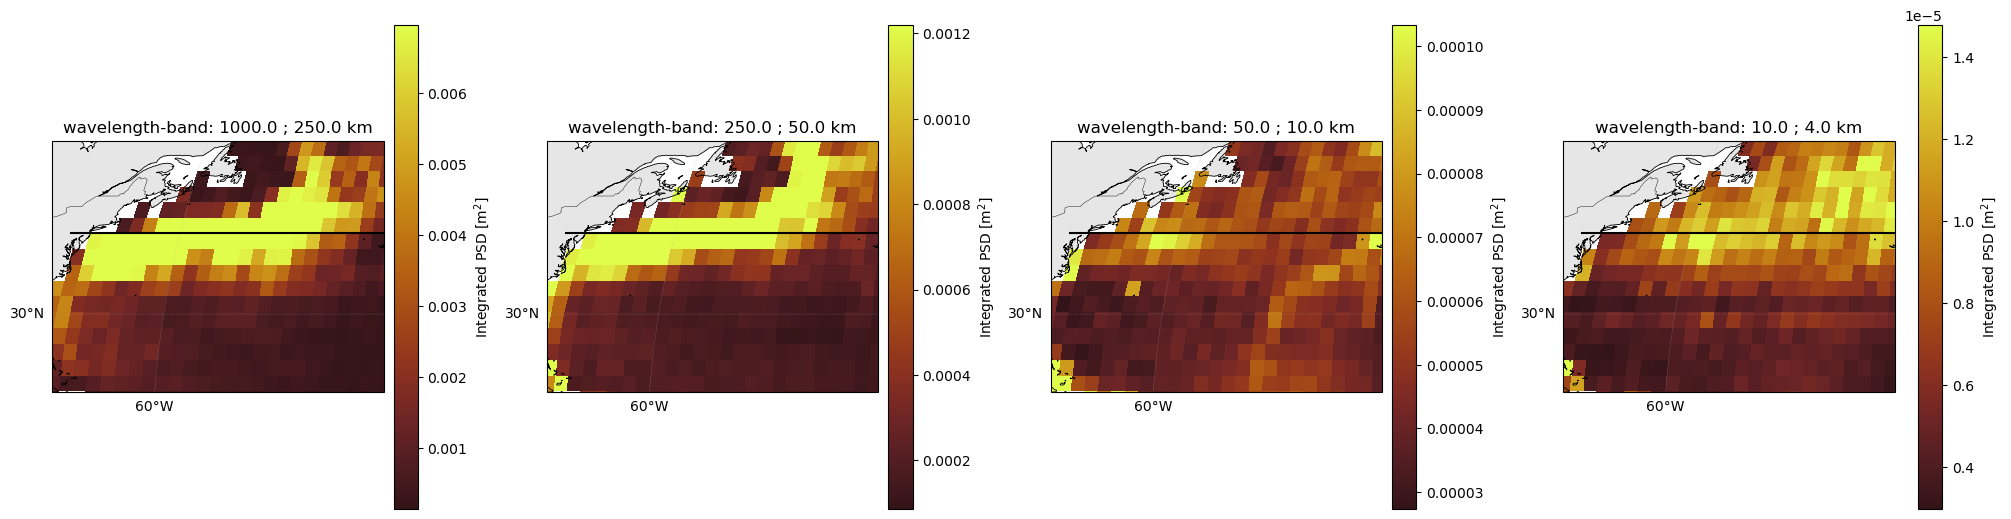

In [54]:
K_MIN, K_MAX = [1/1000,1/250,1/50,1/10], [1/250,1/50,1/10,1/4]
i=0
fig, axs = plt.subplots(1,len(K_MIN),figsize=(20,7),subplot_kw={"projection": ccrs.Robinson()},constrained_layout=True)
for kmin, kmax in zip(K_MIN, K_MAX):
    energy = ds_boxes.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber')
    fig,ax = plot_box(energy,ds_boxes.lon_mean, ds_boxes.lat_mean,
                      title=f'wavelength-band: {1/kmin:.1f} ; {1/kmax:.1f} km',
                      label=r'Integrated PSD [m$^2$]',
                      cmap=cmocean.cm.solar, vmax=np.nanpercentile(energy,95),vmin=np.nanpercentile(energy,5),
                      fig=fig,ax=axs[i])
    ax.set_extent([LON_MIN,LON_MAX,LAT_MIN,LAT_MAX])
    i+=1
    ax.plot([LON_MIN-2.0, LON_MAX+2.0],[40,40], c='k', transform=ccrs.PlateCarree())

In [68]:
latc, dlat = 40.0, 1.0
seg_gser = ds_segments_ex.where((ds_segments_ex.lat_mean<=latc+dlat) & (ds_segments_ex.lat_mean>=latc-dlat)&
                     (ds_segments_ex.lon_mean<=330) & (ds_segments_ex.lon_mean>=280),drop=True).sortby('lon_mean')

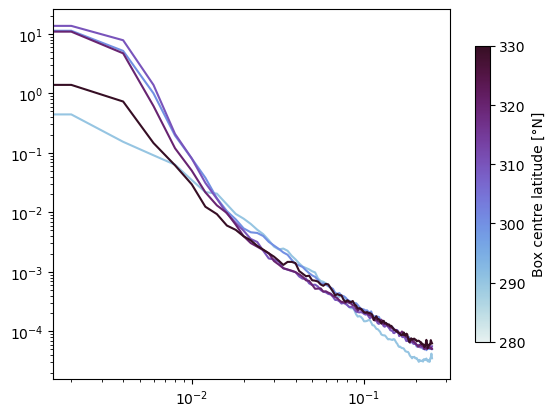

In [72]:
lon_edges = np.arange(280,340,10)
cmap = cmocean.cm.dense
norm = plt.Normalize(vmin=lon_edges[0],vmax=lon_edges[-1])
fig,ax = plt.subplots()
for l in lon_edges:
    _ = seg_gser.where((seg_gser.lon_mean<=l+dlat) & (seg_gser.lon_mean>=l-dlat),drop=True)
    ax.loglog(_.wavenumber.values, _.psd.mean('segment').values,c=cmap(norm(l)))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]",shrink=0.8)